# Tropical Abel-Jacobi for Hyperelliptic Curves
This notebook introduces a tropical perspective on the Abel-Jacobi map by representing a hyperelliptic curve as a metric graph and visualising how divisors map into the Jacobian torus. The examples stay low-dimensional so that the key ideas remain easy to inspect.

## Imports and helper configuration

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Rectangle

plt.style.use('seaborn-v0_8')


## Building a tropical hyperelliptic metric graph

In [3]:
def build_chain_of_loops(genus, loop_length=1.0, bridge_length=1.0):
    """Constructs a chain-of-loops graph of genus `genus`.

    Each loop spans between consecutive backbone vertices so that the final graph has genus `genus`. Edge lengths are tracked in the `length` attribute.
    """
    graph = nx.Graph()
    positions = {}
    spacing = bridge_length + 0.6

    for idx in range(genus + 1):
        node = f"v{idx}"
        graph.add_node(node)
        positions[node] = (idx * spacing, 0.0)

    for idx in range(genus):
        v0, v1 = f"v{idx}", f"v{idx + 1}"
        graph.add_edge(v0, v1, length=bridge_length)

        loop_a = f"l{idx}_a"
        loop_b = f"l{idx}_b"
        graph.add_node(loop_a)
        graph.add_node(loop_b)
        positions[loop_a] = (positions[v0][0], 0.8)
        positions[loop_b] = (positions[v1][0], 0.8)

        third = loop_length / 3
        graph.add_edge(v0, loop_a, length=third)
        graph.add_edge(loop_a, loop_b, length=third)
        graph.add_edge(loop_b, v1, length=third)

    return graph, positions


## The tropical Abel-Jacobi map

In [4]:
def cycle_data(graph, base='v0'):
    cycles = nx.cycle_basis(graph, root=base)
    cycle_lengths = []
    cycle_edges = []

    for cycle in cycles:
        total_length = 0.0
        edges = []
        for start, end in zip(cycle, cycle[1:] + cycle[:1]):
            if graph.has_edge(start, end):
                length = graph[start][end]['length']
            else:
                length = graph[end][start]['length']
            edges.append((start, end))
            total_length += length
        cycle_lengths.append(total_length)
        cycle_edges.append(edges)

    return cycles, cycle_lengths, cycle_edges

def tropical_abel_jacobi_divisor(graph, divisor, base='v0'):
    _, cycle_lengths, _ = cycle_data(graph, base=base)
    distances = nx.single_source_dijkstra_path_length(graph, base, weight='length')
    total_weight = sum(weight for _, weight in divisor)
    total_weight = total_weight if total_weight > 0 else 1

    coords = []
    for cycle_len in cycle_lengths:
        contribution = sum(weight * distances.get(node, 0.0) for node, weight in divisor) / total_weight
        coords.append(contribution % cycle_len if cycle_len > 0 else contribution)

    return np.array(coords), cycle_lengths


## Visualization helpers

In [5]:
def plot_metric_graph(graph, positions, highlight=None, ax=None):
    ax = ax or plt.gca()
    for u, v, data in graph.edges(data=True):
        xs = [positions[u][0], positions[v][0]]
        ys = [positions[u][1], positions[v][1]]
        ax.plot(xs, ys, color='black')
        mid = ((xs[0] + xs[1]) / 2, (ys[0] + ys[1]) / 2)
        ax.text(*mid, f"{data['length']:.2f}", ha='center', va='center', fontsize=8, color='gray')

    node_positions = list(positions.values())
    ax.scatter(*zip(*node_positions), color='black', s=30, zorder=3)
    if highlight is not None:
        for node, weight in highlight:
            if node in positions:
                ax.scatter(*positions[node], s=80 + weight * 20, label=f"{node} (weight={weight})", zorder=4)
    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_xlim(-0.5, max(x for x, _ in positions.values()) + 0.5)
    ax.set_ylim(-0.5, 1.5)
    if highlight is not None:
        ax.legend(loc='upper right', fontsize=8)

def plot_jacobian_projection(coords, cycle_lengths, ax=None):
    ax = ax or plt.gca()
    g = len(coords)
    if g == 0:
        ax.text(0.5, 0.5, 'no cycles', ha='center', va='center')
        return

    if g == 1:
        lim = cycle_lengths[0] if cycle_lengths else 1.0
        ax.plot([0, coords[0]], [0, 0], marker='o')
        ax.set_xlim(-0.1 * lim, 1.1 * lim)
        ax.set_ylim(-0.5, 0.5)
        ax.set_ylabel('dummy coordinate')
        ax.set_xlabel('cycle 1 coordinate')
        ax.add_patch(Rectangle((-0.1 * lim, -0.4), lim * 1.1, 0.8, fill=False, linestyle='--', edgecolor='gray'))
        ax.set_title('Jacobian circle projection')
        return

    xs, ys = coords[0], coords[1] if g >= 2 else (coords[0], 0)
    rect_width = cycle_lengths[0] if cycle_lengths else 1.0
    rect_height = cycle_lengths[1] if len(cycle_lengths) > 1 else 1.0
    ax.add_patch(Rectangle((0, 0), rect_width, rect_height, fill=False, linestyle='--', edgecolor='gray'))
    ax.scatter(xs, ys, s=80, color='tab:red')
    ax.set_xlim(-0.1 * rect_width, rect_width * 1.1)
    ax.set_ylim(-0.1 * rect_height, rect_height * 1.1)
    ax.set_xlabel('cycle 1')
    ax.set_ylabel('cycle 2')
    ax.set_title('Jacobian slice (projection)')


## Example: genus 2 hyperelliptic curve

Jacobian coordinates (mod cycle length): [1.16666667 1.16666667 1.16666667 1.16666667]


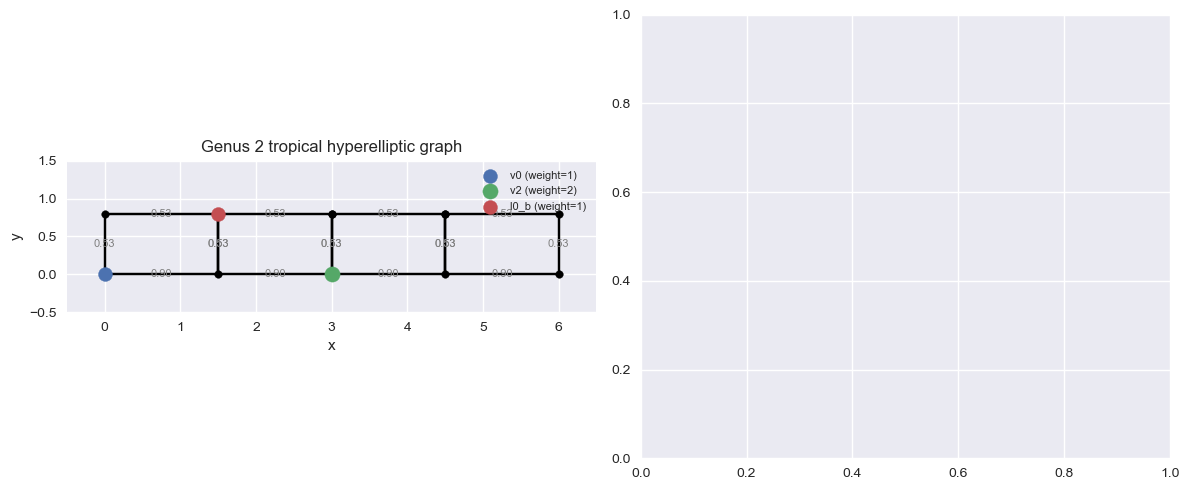

In [ ]:
genus = 4
graph, positions = build_chain_of_loops(genus, loop_length=1.6, bridge_length=0.9)
divisor = [("v0", 1), ("v2", 2), ("l0_b", 1)]
coords, lengths = tropical_abel_jacobi_divisor(graph, divisor)
print("Jacobian coordinates (mod cycle length):", coords)
fig, (ax_graph, ax_jacobian) = plt.subplots(1, 2, figsize=(12, 5))
plot_metric_graph(graph, positions, highlight=divisor, ax=ax_graph)
ax_graph.set_title("Genus 2 tropical hyperelliptic graph")
plot_jacobian_projection(coords, lengths, ax=ax_jacobian)
plt.tight_layout()


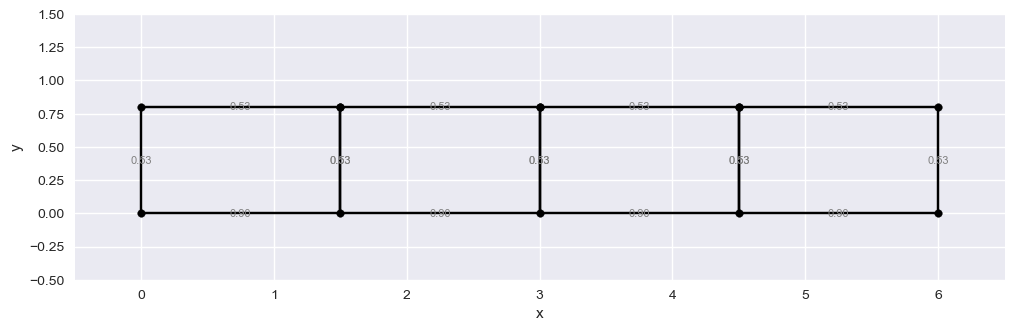

In [12]:
genus = 4
graph, positions = build_chain_of_loops(genus, loop_length=1.6, bridge_length=0.9)
fig, ax_graph = plt.subplots(1, 1, figsize=(12, 5))
plot_metric_graph(graph, positions, ax=ax_graph)